**Shapley $R^2$ decomposition/dominance analysis** (mathematical introduction): 

Quantifiable measure of the marginal contribution to total residual/variance ($R^2$) due to *each* variable compared to a baseline. 

Do a baseline fit, e.g. `(ne, Bt)`, then add a new variable e.g. `Ip` and compute the marginal reduction in total variance, 

$\Delta R^2_{I_p} = R^2(n_e,B_t,I_p) - R^2(n_e,B_t)$.

But notice that one could take `Ip` *before* `Bt`, (or other combinations, even `Ip` *before* `ne` *and/or* `Bt`) and get a different $\Delta R^2$. In this example, since `Ip` and `Bt` tend to be positively correlated, the first one to go into the fit contributes a larger apparent marginal reduction to uncertainty, even though the final fitted exponent will be the same.

The idea of dominance analysis is to average over the $p!$ different orderings for $p$ independent regressors. Take $x_1,...,x_p$ as the candidate regressors. A permutation $\sigma \in S_p$ fixes an ordering. In that ordering, the (fixed) regressor $x_j$ lands in the slot $\sigma^{-1}(j) \equiv k_j$.
The marginal contribution of $x_j$ in that ordering is 

$\overline{\Delta R^2}_j(\sigma) = R^2(x_{\sigma(1)}, ..., x_{\sigma(k_j-1)}, x_j) - R^2(x_{\sigma(1)}, ..., x_{\sigma(k_j-1)}).$

Let the following denote the squared residual of the $m \leq p$ variable fit under the permutation $\sigma,$

$R^2_\sigma (m) \equiv R^2(x_{\sigma(1)}, ... , x_{\sigma(m)})$.

Thus, the average marginal contribution of the regressor $x_j$ over all permutations is

$\overline{\Delta R^2}_j = \frac{1}{p!} \sum_{\sigma \in S_p}\lbrack R^2_{\sigma}(k_j) - R^2_\sigma (k_j - 1) \rbrack,$

where $k_j = \sigma^{-1}(j)$.

**Derivation of formula for OLS variance attribution**

$R^2_\sigma(m)$ (the residual of the $m \leq p$ fit) does *not* depend on the order of the $m$ regressors, only *which $m$* out of the total $p$ regressors in the full set.
Say we have $r$ regressors already, and we want to compute the change in residual due to adding $x_j$ at the slot $k_j = r + 1$. The multiplicity is 

$r! \times 1 \times (p-1-r)! = r!(p-1-r)!$,

i.e. there are r! way to permute the first r regressors, 1 way for $x_j$ fixed, and $(p-1-r)!$ ways for those that remain. Every one of these orderings yields the same summand $R^2(x_{i_1}, ... , x_{i_r}, x_j) - R^2(x_{i_1}, ... , x_{i_r})$, where $i_1 < i_2 < ... < i_r$ (all $i_a \neq j$) is an increasing index sequence of length r from the set $\{1, ..., p\}\setminus j$ of all indices (without j).

Each collection of such indices counts a *unique value* of the summand. So the final average is the sum over such collections, multiplied by the appropriate multiplicity, divided by the total number of permutations, and for every possible $0 \leq r < p$ (not including $r=p$, since $x_j$ is appended to the set of $r$ regressors). i.e.

$\overline{\Delta R^2_j} = \sum_{r=0}^{p-1} \frac{r!(p-1-r)!}{p!} \sum_{i_1 < ... < i_r \, ; \, i_a \neq j} \lbrack R^2(x_{i_1}, ... , x_{i_r}, x_j) - R^2(x_{i_1}, ... , x_{i_r}) \rbrack$.

This is the formula upon which the `shapeley_r2(*)` implementation is based. 










## Notebook Description

Analyses A–C use a **flat baseline (intercept only)**, e.g. `n_e`, `B_t`, and `S` compete on-par alongside every other candidate, to avoid bias towards the conventional scalings.

The three analyses are as follows:

- **A — pooled, both eras, three machines** (AUG/JET/C-Mod): `n_e`, `B_t`, `S`, `I_p`,
  `isotope_mass`, elongation, aspect ratio, heating scheme, wall material. In addition, we have a machine specific offset (multiplying factor) and machine specific exponents for `Ip`, `Bt` and `ne`.
- **B — tc26 only, three machines**: same as A, minus wall material (constant within one era).
- **C — 2008 only, three machines**: same as B minus `isotope_mass` (SELEC2007 is deuterium only).

In [ ]:
import itertools
import math
from collections.abc import Iterable

import numpy as np
import matplotlib.pyplot as plt

import _simdb_common as sc

db = sc.get_db()
MACHINES = ["AUG", "CMOD", "JET"]
NEW_WALL = {2, 10}  # materials_identifier: W, Be
ICRH = {"IC", "NBIC"}  # coarse, cross-machine "uses ion-cyclotron heating" flag
VT_CORNER = {"VT", "CORNER"}  # tc26 JET DIVCON labels in the higher-threshold divertor group


def load_pooled(dataset: str, selec_key: str, machines: list[str]) -> np.ndarray:
    """SELEC-flagged slices for a set of machines, with every variable this notebook tests."""
    rows = []
    for machine in machines:
        sims = sc.query_selected(db, dataset, selec_key, machine=machine)
        for sim in sims:
            md = sim.meta_dict()
            selec = sc.temp(md, selec_key, n=0)
            n = len(selec)
            if n == 0:
                continue
            bt = sc.path(md, "global_quantities", "b0", "value", n=n)
            ne = sc.path(md, "line_average", "n_e", "value", n=n)
            plth = sc.path(md, "global_quantities", "power_loss", "value", n=n)
            pl = sc.temp(md, "PL", n=n)
            splasma = sc.temp(md, "SPLASMA", "area_of_separatrix", n=n)
            meff = sc.path(md, "volume_average", "meff_hydrogenic", "value", n=n)
            kappa = sc.path(md, "boundary", "elongation", "value", n=n)
            rgeo = sc.path(md, "boundary", "geometric_axis_r", "value", n=n)
            amin = sc.path(md, "boundary", "minor_radius", "value", n=n)
            ip = sc.path(md, "global_quantities", "ip", "value", n=n)
            xplimb = sc.temp(md, "XPLIMB", n=n)  # tc26 JET only

            n_slices = min(len(a) for a in
                            (selec, bt, ne, plth, pl, splasma, meff, kappa, rgeo, amin, ip, xplimb))
            if n_slices == 0:
                continue
            sel_mask = selec[:n_slices] == 1
            if not sel_mask.any():
                continue
            pl_eff = np.where(np.isnan(plth[:n_slices]), pl[:n_slices], plth[:n_slices])
            wall_idx = md.get("wall", {}).get("material", {}).get("index", np.nan)
            auxheat_raw = md.get("db_variable", {}).get("AUXHEAT")
            divcon_raw = md.get("db_variable", {}).get("DIVCON")  # tc26 JET only
            for i in np.nonzero(sel_mask)[0]:
                ah = auxheat_raw[i] if auxheat_raw is not None and i < len(auxheat_raw) else None
                dc = divcon_raw[i] if divcon_raw is not None and i < len(divcon_raw) else None
                rows.append((machine, bt[i], ne[i], pl_eff[i], splasma[i], meff[i], kappa[i],
                             rgeo[i], amin[i], ip[i], wall_idx, ah, dc, xplimb[i]))

    dtype = [("machine", "U4"), ("bt", float), ("ne", float), ("pl", float), ("s", float),
             ("meff", float), ("kappa", float), ("rgeo", float), ("amin", float),
             ("ip", float), ("wall_idx", float), ("auxheat", object), ("divcon", object),
             ("XPLIMB", float)]
    return np.array(rows, dtype=dtype)


def valid_mask(d: np.ndarray, require_deuterium: bool = True) -> np.ndarray:
    """All core variables finite/positive; shared by every analysis below.

    require_deuterium restricts to meff ~= 2.0, needed wherever isotope_mass isn't itself a
    free regressor. Only relevant for tc26 data.
    """
    mask = (
        np.isfinite(d["bt"]) & np.isfinite(d["ne"]) & np.isfinite(d["pl"]) & np.isfinite(d["s"])
        & np.isfinite(d["kappa"]) & np.isfinite(d["rgeo"]) & np.isfinite(d["amin"]) & np.isfinite(d["ip"])
        & np.isfinite(d["meff"]) & (d["meff"] > 0)
        & (d["pl"] > 0) & (d["ne"] > 0) & (d["s"] > 0) & (d["kappa"] > 0)
        & (d["rgeo"] > 0) & (d["amin"] > 0) & (d["ip"] != 0)
        & (d["auxheat"] != None)
    )
    if require_deuterium:
        mask &= np.isclose(d["meff"], 2.0, atol=0.05)
    return mask


def _sum_to_zero_codes(machine: np.ndarray, machines: list[str]) -> np.ndarray:
    """Unweighted sum-to-zero (effect) contrast codes for an *arbitrary* list of k machines,
    returned as k-1 columns so every machine -- including the last one -- ends up with its own
    free deviation parameter that sums to zero across all k. E.g. for {AUG, CMOD, JET}: AUG=(1,0),
    JET=(0,1), CMOD=(-1,-1); for a 6-machine list, 5 columns, one per non-reference machine.
    """
    ref = machines[-1]
    cols = [np.where(machine == m, 1.0, np.where(machine == ref, -1.0, 0.0)) for m in machines[:-1]]
    return np.column_stack(cols) if cols else np.zeros((len(machine), 0))


# **named_vars takes declared variables into a dictionary, i.e. machine_slope_blocks(d["machine"],
# MACHINES, ip=log_ip, bt=log_bt, ne=log_ne) -> {"ip": log_ip, "bt": log_bt, "ne": log_ne}
def machine_slope_blocks(machine: np.ndarray, machines: list[str], **named_vars: np.ndarray) -> dict[str, np.ndarray]:
    """Machine-specific variable interaction blocks for capturing device-specific slope heterogeneity, 
    on top of machine_offset's flat per-machine level shift. Uses the same unweighted sum-to-zero coding 
    as machine_offset (see _sum_to_zero_codes) rather than pegging deviations to one reference
    machine."""
    codes = _sum_to_zero_codes(machine, machines)
    return {
        f"machine_{name}": np.column_stack([codes[:, j] * v for j in range(codes.shape[1])])
        for name, v in named_vars.items()
    }


def named_blocks(
    d: np.ndarray, machines: list[str], include_wall: bool, include_isotope: bool = False,
    include_machine_slopes: bool = False, include_divcon_offset: bool = False,
    include_divertor_slopes: bool = False,
) -> dict[str, np.ndarray]:
    """Flat-baseline candidate blocks for Analyses B/C."""
    log_ne = np.log(d["ne"] / 1e20)
    log_bt = np.log(np.abs(d["bt"]))
    log_ip = np.log(np.abs(d["ip"]) / 1e6)
    blocks = {
        "ne": log_ne.reshape(-1, 1),
        "Bt": log_bt.reshape(-1, 1),
        "S": np.log(d["s"]).reshape(-1, 1),
        "elongation": np.log(d["kappa"]).reshape(-1, 1),
        "aspect_ratio": np.log(d["amin"] / d["rgeo"]).reshape(-1, 1),
        "Ip": log_ip.reshape(-1, 1),
        "heating_scheme": np.isin(d["auxheat"], list(ICRH)).astype(float).reshape(-1, 1),
        "machine_offset": _sum_to_zero_codes(d["machine"], machines),
    }
    if include_wall:
        blocks["wall_material"] = np.isin(d["wall_idx"], list(NEW_WALL)).astype(float).reshape(-1, 1)
    if include_isotope:
        blocks["isotope_mass"] = np.log(d["meff"]).reshape(-1, 1)
    if include_machine_slopes:
        blocks.update(machine_slope_blocks(d["machine"], machines, ip=log_ip, bt=log_bt, ne=log_ne))
    if include_divcon_offset:
        blocks["divcon_offset"] = np.isin(d["divcon"], list(VT_CORNER)).astype(float).reshape(-1, 1)
    if include_divertor_slopes:
        divcon_ind = np.isin(d["divcon"], list(VT_CORNER)).astype(float)
        blocks["divcon_bt"] = (divcon_ind * log_bt).reshape(-1, 1)
        blocks["divcon_ip"] = (divcon_ind * log_ip).reshape(-1, 1)
        blocks["divcon_ne"] = (divcon_ind * log_ne).reshape(-1, 1)
    return blocks


def zscore(x: np.ndarray) -> np.ndarray:
    """z score of array"""
    return (x - x.mean()) / x.std()


component_colors = {
    "baseline": "#999999", "wall_material": "tab:orange", "ne": "tab:pink", "Bt": "tab:brown",
    "S": "gold", "elongation": "tab:green", "aspect_ratio": "tab:olive",
    "Ip": "tab:cyan", "heating_scheme": "tab:blue", "machine_offset": "tab:purple",
    "machine_ip": "tab:cyan", "machine_bt": "tab:brown", "machine_ne": "tab:pink",
    "divcon_offset": "tab:red", "divcon_bt": "tab:brown", "divcon_ip": "tab:cyan", "divcon_ne": "tab:pink",
    "isotope_mass": "indigo", "XPLIMB": "slateblue",
    "Bt_ne_interaction": "darkslategray", "Bt_saturation": "firebrick", "ne_saturation": "peru",
    "unexplained": "#dddddd",
}

In [177]:
def shapley_r2(y: np.ndarray, base_cols: np.ndarray, blocks: dict[str, np.ndarray]) -> dict[str, float]:
    """Shapley/LMG decomposition of R^2 among candidate predictor blocks, on top of an
    always-included baseline.

    y: response (1D). base_cols: baseline design matrix, shape: (n_samples, n_base_cols), included in
    every model. blocks: {name: value.shape=(n_samples, n_block_cols)} candidate predictor groups.

    Returns {name: attributed R^2 share}, plus 'baseline' (R^2 with no blocks) and
    'unexplained' (1 - R^2 with all blocks). All values sum to exactly 1.
    """
    names = list(blocks.keys())
    K = len(names)

    def r2_for(subset_names):
        X = np.column_stack([base_cols] + [blocks[n] for n in subset_names])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ coef
        return 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    r2_cache = {
        frozenset(combo): r2_for(combo)
        for r in range(K + 1) for combo in itertools.combinations(names, r)
    }

    shapley = {}
    for g in names:
        others = [n for n in names if n != g]
        total = 0.0
        for r in range(len(others) + 1):
            weight = math.factorial(r) * math.factorial(K - r - 1) / math.factorial(K)
            for combo in itertools.combinations(others, r):
                s = frozenset(combo)
                total += weight * (r2_cache[s | {g}] - r2_cache[s])
        shapley[g] = total

    return {"baseline": r2_for([]), **shapley, "unexplained": 1 - r2_for(names)}

## Analysis B: tc26 only, three machines

Same candidate set as A, minus wall material (constant within a single era), plus `isotope_mass`. No deuterium filter. 

In [178]:
dB = load_pooled("tc26", "SELEC2024", MACHINES)
dB = dB[valid_mask(dB, require_deuterium=False)]
print(f"N = {len(dB)}")

yB = np.log(dB["pl"] / 1e6)
baseB = np.ones(len(dB)).reshape(-1, 1)
resultB = shapley_r2(yB, baseB, named_blocks(dB, MACHINES, include_wall=False, include_isotope=True, include_machine_slopes=True, include_divcon_offset=True, include_divertor_slopes=True))
resultB

N = 475


{'baseline': np.float64(0.0),
 'ne': np.float64(0.04963347746864895),
 'Bt': np.float64(0.008297735452300024),
 'S': np.float64(0.0542854713356421),
 'elongation': np.float64(0.009346505590189284),
 'aspect_ratio': np.float64(0.016494876503179965),
 'Ip': np.float64(0.12460261476336397),
 'heating_scheme': np.float64(0.014517579398970986),
 'machine_offset': np.float64(0.10993786888741941),
 'isotope_mass': np.float64(0.10002393659907037),
 'machine_ip': np.float64(0.08333493021444616),
 'machine_bt': np.float64(0.10303253781999594),
 'machine_ne': np.float64(0.10232791661875125),
 'divcon_offset': np.float64(0.04854496580543426),
 'divcon_bt': np.float64(0.04859176509828607),
 'divcon_ip': np.float64(0.0480778659323744),
 'divcon_ne': np.float64(0.04113679521959921),
 'unexplained': np.float64(0.037813157292326816)}

## B2: tc26, JET excluded

In [179]:
MACHINES_B2 = ["AUG", "CMOD"]
dB2 = load_pooled("tc26", "SELEC2024", MACHINES_B2)
dB2 = dB2[valid_mask(dB2, require_deuterium=False)]
print(f"N = {len(dB2)}")

yB2 = np.log(dB2["pl"] / 1e6)
baseB2 = np.ones(len(dB2)).reshape(-1, 1)
resultB2 = shapley_r2(yB2, baseB2, named_blocks(dB2, MACHINES_B2, include_wall=False, include_isotope=True, include_machine_slopes=True, include_divcon_offset=True, include_divertor_slopes=True))
resultB2

N = 221


{'baseline': np.float64(0.0),
 'ne': np.float64(0.16857644015267656),
 'Bt': np.float64(0.04792759286798864),
 'S': np.float64(0.05887251956971039),
 'elongation': np.float64(0.021446243006319324),
 'aspect_ratio': np.float64(0.033737426730869206),
 'Ip': np.float64(0.13172678209386904),
 'heating_scheme': np.float64(0.05349989895878032),
 'machine_offset': np.float64(0.05349989895878028),
 'isotope_mass': np.float64(0.2121715830129695),
 'machine_ip': np.float64(0.012875201739961381),
 'machine_bt': np.float64(0.057669524821039216),
 'machine_ne': np.float64(0.03990165587473398),
 'divcon_offset': np.float64(7.58125571052934e-18),
 'divcon_bt': np.float64(7.58125571052934e-18),
 'divcon_ip': np.float64(7.58125571052934e-18),
 'divcon_ne': np.float64(7.58125571052934e-18),
 'unexplained': np.float64(0.10809523221230921)}

## Analysis C: 2008 only, ALL machines

Same set as B, on the older carbon/carbon-beryllium-wall era.

In [180]:
MACHINES_C = MACHINES + ["JT60U", "D3D", "JFT2M"]
dC = load_pooled("2008", "SELEC2007", MACHINES_C)
dC = dC[valid_mask(dC)]
print(f"N = {len(dC)}")

yC = np.log(dC["pl"] / 1e6)
baseC = np.ones(len(dC)).reshape(-1, 1)
resultC = shapley_r2(yC, baseC, named_blocks(dC, MACHINES_C, include_wall=False, include_machine_slopes=True))
resultC

N = 1024


{'baseline': np.float64(0.0),
 'ne': np.float64(0.03248998972157615),
 'Bt': np.float64(0.08772855706368979),
 'S': np.float64(0.13201793466000292),
 'elongation': np.float64(0.02164492820124015),
 'aspect_ratio': np.float64(0.05036212214636117),
 'Ip': np.float64(0.20161741614283424),
 'heating_scheme': np.float64(0.007002478716985973),
 'machine_offset': np.float64(0.09373575785471777),
 'machine_ip': np.float64(0.0801342299438036),
 'machine_bt': np.float64(0.10701552898852325),
 'machine_ne': np.float64(0.06285532275125721),
 'unexplained': np.float64(0.1233957338090077)}

## C2: 2008, JET excluded

In [181]:
MACHINES_C2 = [m for m in MACHINES_C if m != "JET"]
dC2 = load_pooled("2008", "SELEC2007", MACHINES_C2)
dC2 = dC2[valid_mask(dC2)]
print(f"N = {len(dC2)}")

yC2 = np.log(dC2["pl"] / 1e6)
baseC2 = np.ones(len(dC2)).reshape(-1, 1)
resultC2 = shapley_r2(yC2, baseC2, named_blocks(dC2, MACHINES_C2, include_wall=False, include_machine_slopes=True))
resultC2

N = 462


{'baseline': np.float64(0.0),
 'ne': np.float64(0.03548872633658596),
 'Bt': np.float64(0.16729073147459517),
 'S': np.float64(0.14593077886612565),
 'elongation': np.float64(0.041753321968975236),
 'aspect_ratio': np.float64(0.08055453316038579),
 'Ip': np.float64(0.2617264393768491),
 'heating_scheme': np.float64(0.012394808157809616),
 'machine_offset': np.float64(0.06655237988514609),
 'machine_ip': np.float64(0.01640995957159388),
 'machine_bt': np.float64(0.0579526031520537),
 'machine_ne': np.float64(0.040457948299238225),
 'unexplained': np.float64(0.07348776975064109)}

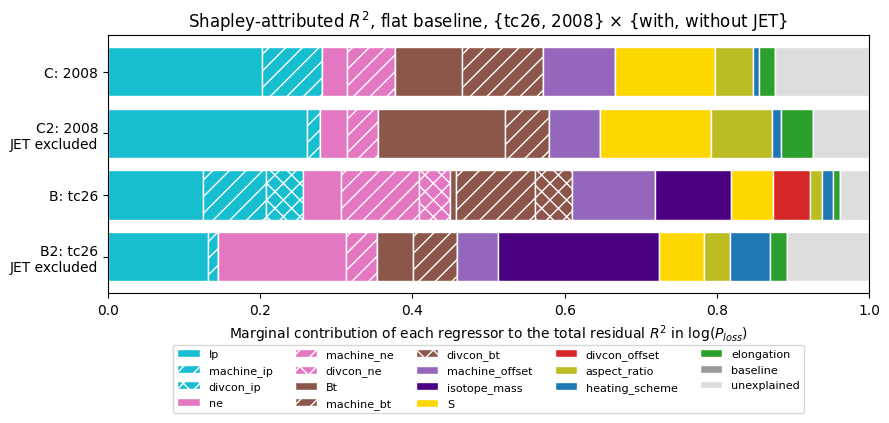

In [182]:
analyses = {
    "B2: tc26\nJET excluded": resultB2,
    "B: tc26": resultB,
    "C2: 2008\nJET excluded": resultC2,
    "C: 2008": resultC,
}

pair_map = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne"}
divcon_map = {"Ip": "divcon_ip", "Bt": "divcon_bt", "ne": "divcon_ne"}
machine_slope_comps = set(pair_map.values())
divcon_slope_comps = set(divcon_map.values())
all_components = set(resultB) | set(resultB2) | set(resultC) | set(resultC2)
primary = [k for k in all_components if k not in machine_slope_comps and k not in divcon_slope_comps and k != "unexplained"]


def pair_total(k):
    total = resultB.get(k, 0.0)
    for pair in (pair_map.get(k), divcon_map.get(k)):
        if pair in all_components:
            total += resultB.get(pair, 0.0)
    return total

component_order_abc = []
for k in sorted(primary, key=pair_total, reverse=True):
    component_order_abc.append(k)
    if pair_map.get(k) in all_components:
        component_order_abc.append(pair_map[k])
    if divcon_map.get(k) in all_components:
        component_order_abc.append(divcon_map[k])
component_order_abc.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(analyses.keys())
bottoms = np.zeros(len(labels))
for comp in component_order_abc:
    vals = np.array([analyses[k].get(comp, 0.0) for k in labels])
    if comp in machine_slope_comps:
        hatch = "//"
    elif comp in divcon_slope_comps:
        hatch = "xx"
    else:
        hatch = None
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
    bottoms += vals

ax.set_xlabel(r"Marginal contribution of each regressor to the total residual $R^2$ in $\log(P_{loss})$")
ax.set_xlim(0, 1)
ax.set_title(r"Shapley-attributed $R^2$, flat baseline, {tc26, 2008} $\times$ {with, without JET}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=5, fontsize=8)
fig.tight_layout()

| | `n_e` total | `B_t` total | `S` | `I_p` total | isotope mass | elongation | aspect ratio | heating scheme | `machine_offset` | `divcon_offset` | unexplained |
|---|---|---|---|---|---|---|---|---|---|---|---|
| B: tc26 | 19.3% | 16.0% | 5.4% | 25.6% | 10.0% | 0.9% | 1.6% | 1.5% | 11.0% | 4.9% | 3.8% |
| B2: tc26, JET excluded | 20.9% | 10.6% | 5.9% | 14.5% | 21.2% | 2.1% | 3.4% | 5.3% | 5.3% | 0.0% | 10.8% |
| C: 2008 | 9.5% | 19.5% | 13.2% | 28.2% | — | 2.2% | 5.0% | 0.7% | 9.4% | — | 12.3% |
| C2: 2008, JET excluded | 7.5% | 22.5% | 14.6% | 27.8% | — | 4.2% | 8.1% | 1.2% | 6.7% | — | 7.3% |

**`B_t`'s device-dominance is specifically a JET effect, not a universal one.** Excluding JET collapses or reverses the common/device split: tc26 goes from common `Bt` 0.8% vs. `machine_bt` 10.3% to near parity (4.8% vs. 5.8%); 2008 fully flips, common `Bt` (16.7%) overtaking `machine_bt` (5.8%).

**Total device-attributable variance** (`machine_offset` + `machine_ip` + `machine_bt` + `machine_ne` +
`divcon_offset` + `divcon_ip` + `divcon_bt` + `divcon_ne`) roughly halves or more once JET is dropped:
58.5% → 16.4% (tc26), 34.4% → 18.1% (2008).

**Divertor configuration is a real, comparable-sized axis of heterogeneity, not just a relabeled JET effect.** `divcon_bt` (4.9%) is close in size to `machine_bt` (10.3%) in tc26, and `divcon_ip`/`divcon_ne` are similar fractions of their own parents — it explains a genuine slice of tc26's device heterogeneity on top of, not instead of, plain machine identity.

## JET, tc26: per-divertor-configuration fits (ne, Bt, Ip)

In [183]:
def fit_loglinear(label, y, fixed=None, **regressors):
    names = list(regressors)
    n = len(y)
    X = np.column_stack([np.ones(n)] + [np.log(regressors[k]) for k in names])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    p = X.shape[1]
    sigma2 = np.sum(resid**2) / max(n - p, 1)
    se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(X.T @ X)))
    rmse = np.sqrt(np.mean(resid**2))
    r2 = 1.0 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    print(f"{label}: N={n}")
    print(f"  C (multiplying factor) = {np.exp(coef[0]):.4g}   [offset = {coef[0]:+.3f} +/- {se[0]:.3f}]")
    for name, val in (fixed or {}).items():
        print(f"  {name} exponent = {val:+.3f} (fixed)")
    for j, name in enumerate(names, start=1):
        print(f"  {name} exponent = {coef[j]:+.3f} +/- {se[j]:.3f}")
    print(f"  RMSE(log) = {rmse:.3f}   R^2 = {r2:.3f}")
    return coef, se


dB_jet = dB[dB["machine"] == "JET"]
is_vtcorner = np.isin(dB_jet["divcon"], list(VT_CORNER))
divcon_groups = {"HT-like (D=1)": dB_jet[~is_vtcorner], "VT/CORNER (D>1)": dB_jet[is_vtcorner]}

print("=== ne, Bt, Ip (S fixed to 1) ===\n")
for label, dg in divcon_groups.items():
    y = np.log(dg["pl"] / 1e6 / dg["s"])
    fit_loglinear(label, y, fixed={"S": 1.0}, ne=dg["ne"] / 1e20, Bt=np.abs(dg["bt"]), Ip=np.abs(dg["ip"]) / 1e6)
    print()

print("=== ne, Bt (S fixed to 1, Ip excluded) -- tests whether the Bt swing above is a Bt/Ip collinearity artifact ===\n")
for label, dg in divcon_groups.items():
    y = np.log(dg["pl"] / 1e6 / dg["s"])
    fit_loglinear(label, y, fixed={"S": 1.0}, ne=dg["ne"] / 1e20, Bt=np.abs(dg["bt"]))
    print()

=== ne, Bt, Ip (S fixed to 1) ===

HT-like (D=1): N=168
  C (multiplying factor) = 0.1543   [offset = -1.869 +/- 0.222]
  S exponent = +1.000 (fixed)
  ne exponent = +1.566 +/- 0.130
  Bt exponent = -0.415 +/- 0.217
  Ip exponent = +0.412 +/- 0.308
  RMSE(log) = 0.291   R^2 = 0.576

VT/CORNER (D>1): N=86
  C (multiplying factor) = 0.04567   [offset = -3.086 +/- 0.313]
  S exponent = +1.000 (fixed)
  ne exponent = +0.377 +/- 0.166
  Bt exponent = +0.174 +/- 0.276
  Ip exponent = +0.463 +/- 0.305
  RMSE(log) = 0.326   R^2 = 0.395

=== ne, Bt (S fixed to 1, Ip excluded) -- tests whether the Bt swing above is a Bt/Ip collinearity artifact ===

HT-like (D=1): N=168
  C (multiplying factor) = 0.1803   [offset = -1.713 +/- 0.189]
  S exponent = +1.000 (fixed)
  ne exponent = +1.645 +/- 0.116
  Bt exponent = -0.176 +/- 0.123
  RMSE(log) = 0.292   R^2 = 0.571

VT/CORNER (D>1): N=86
  C (multiplying factor) = 0.05287   [offset = -2.940 +/- 0.300]
  S exponent = +1.000 (fixed)
  ne exponent = +0.

## JET, 2008: single-machine Shapley, with vs. without XPLIMB

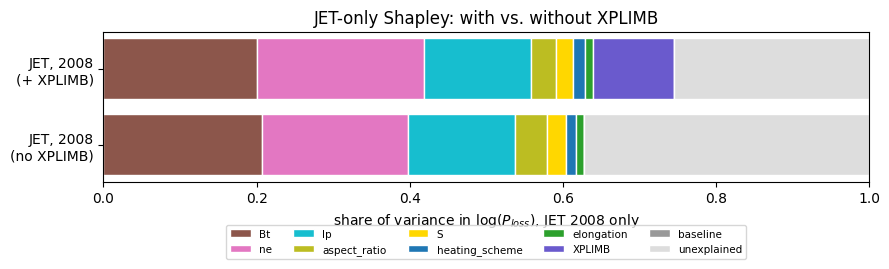

In [184]:
def jet_only_blocks(d: np.ndarray, include_xplimb: bool) -> dict[str, np.ndarray]:
    blocks = named_blocks(d, ["JET"], include_wall=False)
    del blocks["machine_offset"]  # single machine: always zero-width, nothing to show
    if include_xplimb:
        blocks["XPLIMB"] = d["XPLIMB"].reshape(-1, 1)
    return blocks


dC_jet = dC[dC["machine"] == "JET"]
base_jet = np.ones(len(dC_jet)).reshape(-1, 1)
y_jet = np.log(dC_jet["pl"] / 1e6)
result_jet_no_xplimb = shapley_r2(y_jet, base_jet, jet_only_blocks(dC_jet, include_xplimb=False))
result_jet_xplimb = shapley_r2(y_jet, base_jet, jet_only_blocks(dC_jet, include_xplimb=True))

comparison_jet_xplimb = {"JET, 2008\n(no XPLIMB)": result_jet_no_xplimb, "JET, 2008\n(+ XPLIMB)": result_jet_xplimb}

all_components_xplimb = set(result_jet_no_xplimb) | set(result_jet_xplimb)
component_order_xplimb = sorted(
    (k for k in all_components_xplimb if k != "unexplained"),
    key=lambda k: result_jet_no_xplimb.get(k, 0.0), reverse=True,
)
component_order_xplimb.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 3))
labels = list(comparison_jet_xplimb.keys())
bottoms = np.zeros(len(labels))
for comp in component_order_xplimb:
    vals = np.array([comparison_jet_xplimb[k].get(comp, 0.0) for k in labels])
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white")
    bottoms += vals

ax.set_xlabel(r"share of variance in $\log(P_{loss})$, JET 2008 only")
ax.set_xlim(0, 1)
ax.set_title("JET-only Shapley: with vs. without XPLIMB")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=5, fontsize=7.5)
fig.tight_layout()

## Power law vs. symbolic regression (Murari *et al.* 2013), like-for-like on 2008 only

Murari *et al.* 2013 used genetic-programming symbolic regression to search for the best
unconstrained model structure for `P_loss`, without the power-law assumption, and found a 
structure (paper: eq. 5) that is purely additive rather than multiplicative: linear terms in
`n_e`, `B_t`, `S`, `k` (elongation), plus a `B_t·n_e` interaction and two *saturation* terms
(`-B_t^2`, `-n_e^2`). Their AUG/JET fit uses all seven terms; their own CMOD-specific fit drops the
interaction and `B_t^2` term.

The following analysis is motivated to (roughly) test the robustness of variance attribution 
for the same set of regressors across *different model assumptions*, i.e. non-power laws. The comparison
keeps the dataset constant and varies only the model assumption (2008, CMOD+JET+AUG only, SELEC2007 pulses).

The one deliberate departure from the paper is that `log(P_loss)` stays as the response rather than raw 
`P_loss`, so that the two bars remian directly comparable. `n_e`, `B_t`, `S`, and `k` are standardized before 
building the interaction/saturation terms. Centering matters here, since the NPL model is not scale-invariant 
and changes how credit splits between the linear and nonlinear pieces.

In [185]:
ne_z = zscore(dC["ne"] / 1e20)
bt_z = zscore(np.abs(dC["bt"]))
s_z = zscore(dC["s"])
elongation_z = zscore(dC["kappa"])
log_ip_C = np.log(np.abs(dC["ip"]) / 1e6)

blocksC_npl = {
    "ne": ne_z.reshape(-1, 1),
    "Bt": bt_z.reshape(-1, 1),
    "S": s_z.reshape(-1, 1),
    "elongation": elongation_z.reshape(-1, 1),
    "Bt_ne_interaction": (bt_z * ne_z).reshape(-1, 1),
    "Bt_saturation": (bt_z**2).reshape(-1, 1),
    "ne_saturation": (ne_z**2).reshape(-1, 1),
    "aspect_ratio": np.log(dC["amin"] / dC["rgeo"]).reshape(-1, 1),
    "Ip": log_ip_C.reshape(-1, 1),
    "heating_scheme": np.isin(dC["auxheat"], list(ICRH)).astype(float).reshape(-1, 1),
    "machine_offset": _sum_to_zero_codes(dC["machine"], MACHINES_C),
}
blocksC_npl.update(machine_slope_blocks(dC["machine"], MACHINES_C, ip=log_ip_C, bt=bt_z, ne=ne_z))
resultC_npl = shapley_r2(yC, baseC, blocksC_npl)
resultC_npl

{'baseline': np.float64(0.0),
 'ne': np.float64(0.019374862330304603),
 'Bt': np.float64(0.08438427491010109),
 'S': np.float64(0.12651689876858643),
 'elongation': np.float64(0.021778898581314186),
 'Bt_ne_interaction': np.float64(0.008524134116589779),
 'Bt_saturation': np.float64(0.011811495043080395),
 'ne_saturation': np.float64(0.005984272802280285),
 'aspect_ratio': np.float64(0.054284999242987124),
 'Ip': np.float64(0.21768718598126652),
 'heating_scheme': np.float64(0.007649104777538204),
 'machine_offset': np.float64(0.11123315635379383),
 'machine_ip': np.float64(0.08169733382002094),
 'machine_bt': np.float64(0.06384678625721117),
 'machine_ne': np.float64(0.05708297422021967),
 'unexplained': np.float64(0.12814362279470548)}

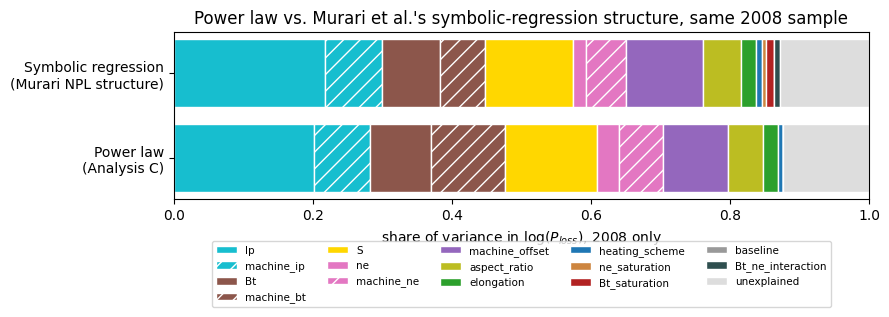

In [186]:
comparisonC_npl = {"Power law\n(Analysis C)": resultC, "Symbolic regression\n(Murari NPL structure)": resultC_npl}

# Same combined-pair-size ordering rule as the A/B/C plot above, using Analysis C (the power-law
# fit) as the reference for ranking so the two bars stay aligned.
pair_map = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne"}
machine_slope_comps = set(pair_map.values())
all_components_npl = set(resultC) | set(resultC_npl)
primary_npl = [k for k in all_components_npl if k not in machine_slope_comps and k != "unexplained"]


def pair_total_npl(k):
    total = resultC.get(k, 0.0)
    pair = pair_map.get(k)
    if pair in all_components_npl:
        total += resultC.get(pair, 0.0)
    return total


component_order_npl = []
for k in sorted(primary_npl, key=pair_total_npl, reverse=True):
    component_order_npl.append(k)
    if pair_map.get(k) in all_components_npl:
        component_order_npl.append(pair_map[k])
component_order_npl.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 3.5))
labels = list(comparisonC_npl.keys())
bottoms = np.zeros(len(labels))
for comp in component_order_npl:
    vals = np.array([comparisonC_npl[k].get(comp, 0.0) for k in labels])
    hatch = "//" if comp in machine_slope_comps else None
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
    bottoms += vals

ax.set_xlabel(r"share of variance in $\log(P_{loss})$, 2008 only")
ax.set_xlim(0, 1)
ax.set_title("Power law vs. Murari et al.'s symbolic-regression structure, same 2008 sample")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=5, fontsize=7.5)
fig.tight_layout()

## The power law beats the symbolic-regression structure (expected), and `I_p`'s split is stable across both, `B_t`'s isn't

| | total $R^2$ | `n_e` total | `B_t` total | `S` | `I_p` total | interaction | elongation | aspect ratio | heating scheme | `machine_offset` | unexplained |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Power law | 75.9% | 13.4% | 18.4% | 6.8% | 23.1% | — | 0.7% | 2.6% | 0.4% | 10.6% | 24.1% |
| Symbolic regression (NPL) | 75.2% | 10.9% | 12.6% | 8.0% | 25.2% | 1.4% | 1.0% | 3.5% | 0.5% | 12.1% | 24.8% |

Total $R^2$ of the power law beats the NPL, however this is expected since the {AUG,CMOD,JET} subset of 2008 database differs from the one used to derive the NPL model, and also since we used `log(P_loss)` instead of `P_loss`

**`I_p`'s common/device-specific split is still stable across both functional forms.** Its common component is 12.7% (power law) vs. 14.2% (NPL), and its device-specific component (`machine_ip`) is 10.4% vs. 11.0%.

** `B_t`'s split is not as stable, however the difference is still concentrated in the device-specific piece. ** Can be partly explained due to saturation and interaction terms with `n_e`.

`machine_offset` itself shifts modestly (10.6% vs. 12.1%) but stays in a similar range under both functional forms.

In [187]:
MU0 = 4 * np.pi * 1e-7


def bpol_blocks(d: np.ndarray, machines: list[str], include_isotope: bool = False, include_divcon_offset: bool = False) -> dict[str, np.ndarray]:
    """Same candidate set as named_blocks, with Bt and Ip replaced by the poloidally averaged
    Bpol = 2*pi*mu0*Ip*R/S at the separatrix."""
    blocks = named_blocks(d, machines, include_wall=False, include_isotope=include_isotope,
                           include_machine_slopes=False, include_divcon_offset=include_divcon_offset)
    log_bpol = np.log(2 * np.pi * MU0 * np.abs(d["ip"]) * d["rgeo"] / d["s"])
    del blocks["Ip"], blocks["Bt"]
    blocks["Bpol"] = log_bpol.reshape(-1, 1)
    blocks.update(machine_slope_blocks(d["machine"], machines, bpol=log_bpol, ne=np.log(d["ne"] / 1e20)))
    return blocks


resultB_bpol = shapley_r2(yB, baseB, bpol_blocks(dB, MACHINES, include_isotope=True, include_divcon_offset=True))
resultB_bpol

{'baseline': np.float64(0.0),
 'ne': np.float64(0.05905223356095919),
 'S': np.float64(0.10179250034517884),
 'elongation': np.float64(0.012930256713424671),
 'aspect_ratio': np.float64(0.02091683240930183),
 'heating_scheme': np.float64(0.015145183766761484),
 'machine_offset': np.float64(0.17535626044426972),
 'isotope_mass': np.float64(0.10631533409089017),
 'divcon_offset': np.float64(0.10762065199879602),
 'Bpol': np.float64(0.05850228079823707),
 'machine_bpol': np.float64(0.14199854926064434),
 'machine_ne': np.float64(0.15465181013531526),
 'unexplained': np.float64(0.045718106476220655)}

In [188]:
resultC_bpol = shapley_r2(yC, baseC, bpol_blocks(dC, MACHINES_C))
resultC_bpol

{'baseline': np.float64(0.0),
 'ne': np.float64(0.044189485308518114),
 'S': np.float64(0.2039332456767404),
 'elongation': np.float64(0.03209029642987162),
 'aspect_ratio': np.float64(0.07023519718862156),
 'heating_scheme': np.float64(0.010715762926926704),
 'machine_offset': np.float64(0.13298991673062843),
 'Bpol': np.float64(0.19374125846503304),
 'machine_bpol': np.float64(0.08952533162053039),
 'machine_ne': np.float64(0.08263968650910233),
 'unexplained': np.float64(0.13993981914402753)}

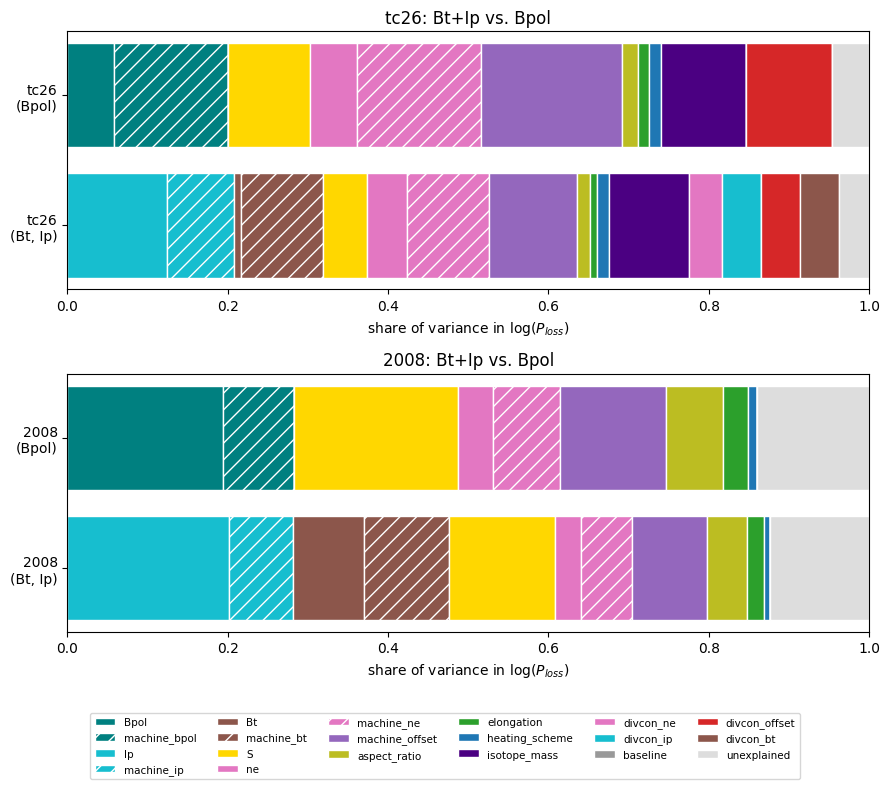

In [189]:
component_colors["Bpol"] = "teal"
component_colors["machine_bpol"] = "teal"

# Shared ordering across both subplots, ranked by magnitude in the 2008 (bottom) chart, with
# Bpol/machine_bpol pinned to the front regardless of size.
pair_map_bpol = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne", "Bpol": "machine_bpol"}
slope_comps_bpol = set(pair_map_bpol.values())
all_comps_bpol = set(resultB) | set(resultB_bpol) | set(resultC) | set(resultC_bpol)
primary_bpol = [k for k in all_comps_bpol if k not in slope_comps_bpol and k not in ("unexplained", "Bpol")]


def pair_total_bpol(k):
    total = resultC.get(k, 0.0)
    pair = pair_map_bpol.get(k)
    if pair in all_comps_bpol:
        total += resultC.get(pair, 0.0)
    return total


shared_order = ["Bpol", "machine_bpol"]
for k in sorted(primary_bpol, key=pair_total_bpol, reverse=True):
    shared_order.append(k)
    if pair_map_bpol.get(k) in all_comps_bpol:
        shared_order.append(pair_map_bpol[k])
shared_order.append("unexplained")


def bpol_bar(ax, result_orig, result_bpol, labels, title, order):
    comparison = {labels[0]: result_orig, labels[1]: result_bpol}
    bottoms = np.zeros(2)
    for comp in order:
        vals = np.array([comparison[k].get(comp, 0.0) for k in labels])
        hatch = "//" if comp in slope_comps_bpol else None
        ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
        bottoms += vals
    ax.set_xlabel(r"share of variance in $\log(P_{loss})$")
    ax.set_xlim(0, 1)
    ax.set_title(title)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7))
bpol_bar(ax1, resultB, resultB_bpol, ["tc26\n(Bt, Ip)", "tc26\n(Bpol)"], "tc26: Bt+Ip vs. Bpol", shared_order)
bpol_bar(ax2, resultC, resultC_bpol, ["2008\n(Bt, Ip)", "2008\n(Bpol)"], "2008: Bt+Ip vs. Bpol", shared_order)
handles, labels_ = ax2.get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=6, fontsize=7.5)
fig.tight_layout()